# Elevator Simulation v0.5

*Finished Date: th May 2021*

In [1]:
from collections import defaultdict
from copy import copy, deepcopy
from dataclasses import dataclass
from functools import partial
from typing import Optional
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from tqdm.notebook import tqdm

In [2]:
np.set_printoptions(suppress=True)
plt.style.use("bmh")
config = {'figure.figsize': (16, 4),
          'axes.titlesize': 22,
          'axes.labelsize': 14,
          'lines.linewidth': 2,
          'lines.markersize': 10,
          'xtick.labelsize': 10,
          'ytick.labelsize': 10,
          'axes.prop_cycle': plt.cycler(color=["darkmagenta", "saddlebrown", "darkcyan", "olivedrab", "darkseagreen", "darkkhaki", "darkgoldenrod", "deepskyblue", "firebrick", "palevioletred"]),}
plt.rcParams.update(config)

<div class="alert alert-success"><h1>Classes Definition</h1></div>

In [3]:
@dataclass
class User:
    origin: int
    destination: int
    waiting_tolerance: float
    arrive_time: float
    enter_elevator_time: Optional[float] = None
    arrive_destination_time: Optional[float] = None

In [4]:
@dataclass
class ElevatorCall:
    timestamp: float
    type_: str
    floor: int
    
    def __hash__(self):
        return hash(str(self.timestamp) + self.type_ + str(self.floor))

In [5]:
@dataclass
class Elevator:
    capacity: int
    floor_time: float
    doors_time: float
    person_time: float
    state: str
    current_floor: int
    next_floor: int
    current_people: list
    doors: str
    calls: list

In [6]:
@dataclass
class Scenario:
    distribution_parameters: list
    duration: float
    floor_destination_probabilities: dict
    start_datetime: float
    waiting_tolerance: tuple

<div class="alert alert-danger"><h1>Events</h1></div>

### User Arrival

In [7]:
def user_arrival(state_, constants):
    
    state = copy(state_)
    
    arrival_floor = state.next_arrival_floor
    
    # Get user destination
    destination_floor = get_user_destination(state, constants, arrival_floor)
    
    # Create user
    user = User(arrive_time=state.current_event_time,
                origin=arrival_floor,
                destination=destination_floor,
                waiting_tolerance=get_user_waiting_tolerance(state),
               )
    
    # Add user to queue
    state.floors_queues[user.origin] = tuple(state.floors_queues[user.origin]) + (user,)
    
    # Set next arrival time for current floor
    next_arrival_time = np.abs(state.PRNGs_floors_arrival[arrival_floor]())
    state.events.user_arrival[arrival_floor] = state.current_event_time + next_arrival_time

    # Get floor of next arrival
    state.next_arrival_floor = get_next_arrival(state.events.user_arrival)
    
    # If user can enter, go to load and unload if not called, and disable move elevator
    if user_can_enter(state, user.origin) and state.events.load_and_unload == np.inf and state.events.enter_elevator == np.inf:
        state.events.load_and_unload = state.current_event_time
        state.events.move_elevator_one_floor = np.inf
        return state
    
    # If user cannot enter and button is not pressed, press button
    if not button_pressed(state.elevator.calls, user.origin, 'outside'):
        elevator_call = ElevatorCall(state.current_event_time, 'outside', user.origin) 
        state.elevator.calls.append(elevator_call)
    
    # If no other elevator event is programmed
    if list(vars(state.events).values())[1:] == [np.inf, np.inf, np.inf, np.inf]:
        state.events.process_calls = state.current_event_time
        
    return state

####################

def get_user_destination(state, constants, origin_floor):
    
    probabilities = constants.floor_destination_probabilities[str(origin_floor)]
    destination_floor = state.PRNG_choice(constants.floors_ids, p=probabilities)
     
    return destination_floor

####################

def get_user_waiting_tolerance(state):
    return state.PRNG_waiting_tolerance()

####################

def get_next_arrival(next_arrivals):
    
    next_arrival =  min(next_arrivals.items(), key=lambda x: x[1])

    return next_arrival[0]

####################

def user_can_enter(state, origin_floor):
    
    correct_position = state.elevator.current_floor == origin_floor
    enough_space = state.elevator.capacity - len(state.elevator.current_people)
    people_in_queue = len(state.floors_queues[state.elevator.current_floor])
    doors_open = state.elevator.doors == 'open'
    
    return correct_position and enough_space > 0 and people_in_queue > 0 and doors_open

####################

def button_pressed(calls, current_floor, kind):
    return any(call.floor == current_floor and call.type_ == kind for call in calls)

### Process Calls

In [8]:
def process_calls(state_, constants):

    state = copy(state_)
    state.events.process_calls = np.inf

    state.elevator = apply_dispatching_algorithm(state, constants)
    
    if state.elevator.next_floor is None:
        return state
    
    if state.elevator.next_floor == np.inf:
        state.events.process_calls = state.current_event_time
        return state

    # If elevator on destination floor
    if state.elevator.next_floor == state.elevator.current_floor:
        state.events.load_and_unload = state.current_event_time + state.elevator.doors_time
        return state
    
    # Do not consider doors time if they are closed
    doors_time = state.elevator.doors_time * (state.elevator.doors == 'open')
    state.events.move_elevator_one_floor = state.current_event_time + doors_time

    return state

### Move Elevator One Floor

In [9]:
def move_elevator_one_floor(state_, constants):
    
    state = copy(state_)
    
    state.events.move_elevator_one_floor = np.inf
    
    state.elevator.doors = 'close'
    
    delta = 1 if state.elevator.next_floor > state.elevator.current_floor else -1
    
    state.elevator.current_floor = state.elevator.current_floor + delta
    
    state.events.process_calls = state.current_event_time + state.elevator.floor_time
    
    return state

### Load and Unload in Floor

In [10]:
def load_and_unload(state_, constants):
    
    state = copy(state_)
    
    state.events.load_and_unload = np.inf
    
    # Open Doors
    state.elevator.doors = 'open'
    
    elevator_previous_people = len(state.elevator.current_people)
    
    # Delete calls of current floor
    state.elevator.calls = [call for call in state.elevator.calls if call.floor != state.elevator.current_floor]
    
    # Users get off the elevator in destination
    people_in_elevator = []
    for person in state.elevator.current_people:
        if person.destination != state.elevator.current_floor:
            people_in_elevator.append(person)
        else:
            person.arrive_destination_time = state.current_event_time
            state.users_served.append(person)
            
    state.elevator.current_people = people_in_elevator
    
    people_unload_time = (elevator_previous_people - len(state.elevator.current_people)) * state.elevator.person_time
    
    # Delete people that have left queue
    def wait_time_excedeed(person):
        return state.current_event_time <= person.arrive_time + person.waiting_tolerance
    
    users_in_queue = state.floors_queues[state.elevator.current_floor]
    
    state.floors_queues[state.elevator.current_floor] = list(filter(wait_time_excedeed, users_in_queue))
    
    # If users can enter, go to enter elevator
    if user_can_enter(state, state.elevator.current_floor):
        state.events.enter_elevator = state.current_event_time + state.elevator.person_time
        return state
    
    # If users left in floor, add call for current floor
    if state.floors_queues[state.elevator.current_floor]:
        elevator_call = ElevatorCall(state.current_event_time, 'outside', state.elevator.current_floor) 
        state.elevator.calls.append(elevator_call)
    
    # Otherwise, process calls
    state.events.process_calls = state.current_event_time + people_unload_time
    
    return state

### Enter Elevator

In [11]:
def enter_elevator(state_, constants):
    
    state = copy(state_)
    
    state.events.enter_elevator = np.inf
          
    # Get first user of queue and delete it from queue
    user, *rest = state.floors_queues[state.elevator.current_floor]
    state.floors_queues[state.elevator.current_floor] = rest
    user.enter_elevator_time = state.current_event_time
    
    # Add user to elevator
    state.elevator.current_people.append(user)
    
    # If not already pressed, user presses a button. Create an elevator inside call
    if not button_pressed(state.elevator.calls, user.destination, 'inside'):
        elevator_call = ElevatorCall(state.current_event_time, 'inside', user.destination)
        state.elevator.calls.append(elevator_call)
    
    # If more users can enter, repeat the event
    if user_can_enter(state, user.origin):
        state.events.enter_elevator = state.current_event_time + state.elevator.person_time
        return state
    
    # If no more users can enter and there are users left in queue, press button again
    if state.floors_queues[state.elevator.current_floor]:
        elevator_call = ElevatorCall(state.current_event_time, 'outside', state.elevator.current_floor) 
        state.elevator.calls.append(elevator_call)
    
    state.events.process_calls = state.current_event_time
    
    return state

<div class="alert alert-danger"><h1>Auxiliary Functions</h1></div>

#### Generate PRNG

In [12]:
def generate_PRNGs(constants):
    
    PRNGs_floors_arrival = {}
    
    for i, parameters in enumerate(constants.distribution_parameters):
        PRNGs_floors_arrival[i] = partial(np.random.RandomState(constants.seed + i).gamma, parameters[0], parameters[1])
    
    PRNG_choice = np.random.RandomState(constants.seed - 1).choice
    PRNG_waiting_tolerance = partial(np.random.RandomState(constants.seed - 2).gamma, constants.waiting_tolerance[0], constants.waiting_tolerance[1])
    
    return PRNGs_floors_arrival, PRNG_choice, PRNG_waiting_tolerance

#### Get Next Event

In [13]:
def get_next_event(events):
    
    events_dict = vars(events)
    best_name = list(events_dict.keys())[0]
    event_timestamp = events_dict[best_name]
    
    if isinstance(event_timestamp, dict):
        best_timestamp = list(event_timestamp.values())
    elif not isinstance(event_timestamp, list):
        best_timestamp = [event_timestamp]
    
    best_timestamp = min(best_timestamp)
    for event_name, event_timestamp in events_dict.items():
        if isinstance(event_timestamp, dict):
            event_timestamp = list(event_timestamp.values())
        
        elif not isinstance(event_timestamp, list):
            event_timestamp = [event_timestamp]

        timestamp = min(event_timestamp)
        if timestamp < best_timestamp:
            best_timestamp = timestamp
            best_name = event_name
    
    return best_name, best_timestamp

#### Update Data

In [14]:
def update_data(state, data_, ignored_keys):
    
    data = copy(data_)
    state_dict = vars(state)
    for key in state_dict.keys():
        if key in ignored_keys:
            continue
        data[key].append(deepcopy(state_dict[key]))
    
    return data

<div class="alert alert-info"><h1>Dispatching Algorithms</h1></div>

In [15]:
def apply_dispatching_algorithm(state, constants):
    
    kind = constants.dispatching_algorithm
        
    if kind == 'FIFO':
        return FIFO(state)
    
    if kind == 'IFOF':
        return IFOF(state)
    
    if kind == 'LOOK':
        return LOOK(state)
    
    if kind == 'LOOK_M':
        return LOOK_M(state)
    
    return None

### FIFO

In [16]:
def FIFO(state_):
    
    state = copy(state_)
    
    if not state.elevator.calls: 
        state.elevator.next_floor = None
        state.elevator.state = 'idle'
        return state.elevator
        
    state.elevator.state = 'busy'
    state.elevator.next_floor = int(state.elevator.calls[0].floor)
        
    return state.elevator

### IFOF

In [17]:
def IFOF(state_):
    
    state = copy(state_)
    
    if not state.elevator.calls:
        state.elevator.next_floor = None
        state.elevator.state = 'idle'
        return state.elevator
    
    outside_calls = [call for call in state.elevator.calls if call.type_ == 'outside']
    inside_calls = [call for call in state.elevator.calls if call.type_ == 'inside']
    
    state.elevator.state = 'busy'
    state.elevator.next_floor = int(inside_calls[0].floor if inside_calls else outside_calls[0].floor)
    
    return state.elevator

### LOOK

In [18]:
def LOOK(state_):
    
    state = copy(state_)
    
    # If there are no calls, become idle
    if not state.elevator.calls:
        state.elevator.state = 'idle'
        state.elevator.next_floor = None
        return state.elevator
        
    # If moving up, get upper calls, if any
    inside_calls = np.array([call.floor for call in state.elevator.calls if call.type_ == 'inside'])
    outside_calls = np.array([call.floor for call in state.elevator.calls if call.type_ == 'outside'])
    
    # Check outside calls in current floor. If enough space, stop in current floor
    if any(floor == state.elevator.current_floor for floor in outside_calls):
        if state.elevator.capacity - len(state.elevator.current_people):
            state.elevator.next_floor = int(state.elevator.current_floor)
            return state.elevator
    
    upper_inside_calls = inside_calls[inside_calls >= state.elevator.current_floor]
    upper_outside_calls = outside_calls[outside_calls > state.elevator.current_floor]
    upper_calls = np.append(upper_inside_calls, upper_outside_calls)
    
    # If moving up, get upper calls, if any 
    if len(upper_calls) and (state.elevator.state == 'up'):
        state.elevator.next_floor = int(np.min(upper_calls))
        return state.elevator
    
    # If no upper calls, go down and get lower calls
    state.elevator.state = 'down'
    lower_inside_calls = inside_calls[inside_calls <= state.elevator.current_floor]
    lower_outside_calls = outside_calls[outside_calls < state.elevator.current_floor]
    lower_calls = np.append(lower_inside_calls, lower_outside_calls)
    
    # If no lower calls, go up
    if not len(lower_calls):
        state.elevator.state = 'up'
        state.elevator.next_floor = np.inf
        return state.elevator
    
    # If lower calls, get the highest
    state.elevator.next_floor = int(np.max(lower_calls))
    
    return state.elevator

### LOOK-M

In [19]:
def LOOK_M(state_):
    
    state = copy(state_)
    
    # If there are no calls, become idle
    if not state.elevator.calls:
        state.elevator.state = 'idle'
        state.elevator.next_floor = None
        return state.elevator
        
    # If moving up, get upper inside calls, if any
    inside_calls = np.array([call.floor for call in state.elevator.calls if call.type_ == 'inside'])
    upper_inside_calls = inside_calls[inside_calls >= state.elevator.current_floor]
    if len(upper_inside_calls) and (state.elevator.state == 'up'):
        state.elevator.next_floor = int(np.min(upper_inside_calls))
        return state.elevator
    
    # Check outside calls in current floor. If enough space, stop in current floor
    outside_calls = np.array([call.floor for call in state.elevator.calls if call.type_ == 'outside'])
    if any(floor == state.elevator.current_floor for floor in outside_calls):
        if state.elevator.capacity - len(state.elevator.current_people):
            state.elevator.next_floor = int(state.elevator.current_floor)
            return state.elevator
    
    # If moving up, get upper outside calls, if any 
    upper_outside_calls = outside_calls[outside_calls > state.elevator.current_floor]
    if len(upper_outside_calls) and (state.elevator.state == 'up'):
        state.elevator.next_floor = int(np.min(upper_outside_calls))
        return state.elevator
    
    # If no upper calls, go down and get lower calls
    state.elevator.state = 'down'
    lower_inside_calls = inside_calls[inside_calls <= state.elevator.current_floor]
    lower_outside_calls = outside_calls[outside_calls < state.elevator.current_floor]
    lower_calls = np.append(lower_inside_calls, lower_outside_calls)
    
    # If no lower calls, go up
    if not len(lower_calls):
        state.elevator.state = 'up'
        state.elevator.next_floor = np.inf
        return state.elevator
    
    # If lower calls, get the highest
    state.elevator.next_floor = int(np.max(lower_calls))
    
    return state.elevator

<div class="alert alert-warning"><h1>Scenarios</h1></div>

In [20]:
def create_scenario(kind):
    
    M = 60
    H = 3600
    D = 86400
    
    if kind == 'residential_building':
    
        distribution_parameters = [(1*H, 1), (4*H, 1), (4*H, 1), (4*H, 1), (4*H, 1), (4*H, 1)]
        duration = 12*D
        start_datetime = pd.to_datetime('2021-05-1 08:00:00').timestamp()
        waiting_tolerance = (np.inf, np.inf)
        floor_destination_probabilities = {'0': [0.00, 0.05, 0.2375, 0.2375, 0.2375, 0.2375],
                                           '1': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '2': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '3': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '4': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '5': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],}
    

    if kind == 'morning_rush':
    
        distribution_parameters = [(5, 1), (np.inf, np.inf), (np.inf, np.inf), (np.inf, np.inf), (np.inf, np.inf), (np.inf, np.inf)]
        duration = 20*M 
        start_datetime = pd.to_datetime('2021-05-1 08:00:00').timestamp()
        waiting_tolerance = (np.inf, np.inf)
        floor_destination_probabilities = {'0': [0.00, 0.20, 0.20, 0.20, 0.20, 0.20],
                                           '1': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '2': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '3': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '4': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '5': [0.00, 0.00, 0.00, 0.00, 0.00, 0.00],}

    elif kind == 'lunchtime':
        
        distribution_parameters = [(20, 1), (20, 1), (10, 1), (10, 1), (10, 1), (10, 1)]
        duration = 90*M
        start_datetime = pd.to_datetime('2021-05-1 13:00:00').timestamp()
        waiting_tolerance = (np.inf, np.inf)
        floor_destination_probabilities = {'0': [0.00, 0.20, 0.20, 0.20, 0.20, 0.20],
                                           '1': [0.20, 0.00, 0.20, 0.20, 0.20, 0.20],
                                           '2': [0.50, 0.50, 0.00, 0.00, 0.00, 0.00],
                                           '3': [0.50, 0.50, 0.00, 0.00, 0.00, 0.00],
                                           '4': [0.50, 0.50, 0.00, 0.00, 0.00, 0.00],
                                           '5': [0.50, 0.50, 0.00, 0.00, 0.00, 0.00],}
        
        
    elif kind == 'evening_rush':
        
        distribution_parameters = [(np.inf, np.inf), (30, 1), (25, 1), (6, 1), (5, 1), (5, 1)]
        duration = 30*M 
        start_datetime = pd.to_datetime('2021-05-1 17:00:00').timestamp()
        waiting_tolerance = (np.inf, np.inf)
        floor_destination_probabilities = {'0': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '1': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '2': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '3': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '4': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],
                                           '5': [1.00, 0.00, 0.00, 0.00, 0.00, 0.00],}
        
    return Scenario(distribution_parameters = distribution_parameters,
                    duration = duration,
                    floor_destination_probabilities = floor_destination_probabilities,
                    start_datetime = start_datetime,
                    waiting_tolerance = waiting_tolerance)

<div class="alert alert-success"><h1>Main Simulation</h1></div>

In [21]:
def elevator_simulation(dispatching_algorithm, scenario, elevator_capacity=None, elevator_doors_time=None, elevator_floor_time=None, elevator_person_time=None, num_floors=None, seed=None, **kwargs):
    
    #-------- Scenario
    scenario = create_scenario(kind=scenario)

    #-------- Constants
    constants = SimpleNamespace(
        distribution_parameters = scenario.distribution_parameters,
        floors_ids = np.arange(0, num_floors),
        floor_destination_probabilities = scenario.floor_destination_probabilities,
        start_datetime = scenario.start_datetime,
        seed = seed,
        dispatching_algorithm = dispatching_algorithm,
        duration = scenario.duration,
        waiting_tolerance = scenario.waiting_tolerance,
    )
    
    # Generate PRNGs 
    PRNGs_floors_arrival, PRNG_choice, PRNG_waiting_tolerance = generate_PRNGs(constants)

    #-------- Generate next arrivals
    next_arrivals = {floor_id: constants.start_datetime + floor_generator() for floor_id, floor_generator in PRNGs_floors_arrival.items()}
    next_arrival_floor = get_next_arrival(next_arrivals)

    #-------- Elevator
    elevator = Elevator(capacity = elevator_capacity, floor_time = elevator_floor_time, doors_time = elevator_doors_time, person_time = elevator_person_time, state='up', current_floor=0, next_floor=0, current_people=[], doors='open', calls=[])
    
    #-------- State
    state = SimpleNamespace(
        elevator = elevator,
        PRNG_choice = PRNG_choice,
        PRNGs_floors_arrival = PRNGs_floors_arrival,
        PRNG_waiting_tolerance = PRNG_waiting_tolerance,
        floors_queues = defaultdict(tuple),
        next_arrival_floor = next_arrival_floor,
        users_served = [],
    )
    
    #-------- Events
    state.events = SimpleNamespace(
        user_arrival = next_arrivals,
        process_calls = np.inf,
        move_elevator_one_floor = np.inf,
        enter_elevator = np.inf,
        load_and_unload = np.inf,
    )
    
    #-------- Generate current time
    _, current_event_time = get_next_event(state.events)
    state.current_event_time = current_event_time

    #-------- Save initial values
    data = defaultdict(list)
    ignored_keys = ['next_arrival_floor', 'events', 'users_served', 'PRNGs_floors_arrival', 'PRNG_choice', 'PRNG_waiting_tolerance']
    data = update_data(state, data, ignored_keys)

    #-------- Set simulation end time
    end_time = constants.duration + current_event_time
    
    progress_bar = tqdm(total=end_time - current_event_time, bar_format='{l_bar}{bar}| {n:.4f}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]')
    
    while state.current_event_time < end_time:

        previous = state.current_event_time
        current_event_type, state.current_event_time = get_next_event(state.events)

        progress_bar.update(round(state.current_event_time - previous, 2))

        if current_event_type == 'user_arrival':
            state = user_arrival(state, constants)

        elif current_event_type == 'move_elevator_one_floor':
            state = move_elevator_one_floor(state, constants)

        elif current_event_type == 'process_calls':
            state = process_calls(state, constants)

        elif current_event_type == 'enter_elevator':
            state = enter_elevator(state, constants)

        elif current_event_type == 'load_and_unload':
            state = load_and_unload(state, constants)

        data = update_data(state, data, ignored_keys)

    data['users_served'] = state.users_served
    data['duration'] = constants.duration
    data['start_datetime'] = constants.start_datetime
    
    progress_bar.close()
    
    return data

<div class="alert alert-info"><h1>Parameters</h1></div>

In [22]:
parameters = {
    'elevator_capacity' : 6,
    'elevator_doors_time' : 3,
    'elevator_floor_time' : 5,
    'elevator_person_time' : 1,
    'num_floors' : 6,
    'seed' : 40,
}
dispatching_algorithm = 'LOOK_M'
scenario = 'morning_rush'

<div class="alert alert-warning"><h1>Run Simulation</h1></div>

In [23]:
data = elevator_simulation(dispatching_algorithm, scenario, **parameters)

  0%|          | 0.0000/1200.0 [00:00<?, ?it/s]

<div class="alert alert-success"><h1>Post Processing</h1></div>

In [24]:
columns = ['current_event_time', 'elevator', 'floors_queues']
df = pd.DataFrame(columns=columns)

data_ = data.copy()
del data_['users_served']
del data_['duration']
del data_['start_datetime']

df = df.append(pd.DataFrame(data_), ignore_index=True)
df = df.set_index('current_event_time')
# df.index = pd.to_datetime(df.index, unit='s')
df

,elevator,floors_queues
current_event_time,,
1.619856e+09,"Elevator(capacity=6, floor_time=5, doors_time=...",{}
1.619856e+09,"Elevator(capacity=6, floor_time=5, doors_time=...","{0: (User(origin=0, destination=3, waiting_tol..."
1.619856e+09,"Elevator(capacity=6, floor_time=5, doors_time=...","{0: [User(origin=0, destination=3, waiting_tol..."
1.619856e+09,"Elevator(capacity=6, floor_time=5, doors_time=...",{0: []}
1.619856e+09,"Elevator(capacity=6, floor_time=5, doors_time=...",{0: []}
...,...,...
1.619857e+09,"Elevator(capacity=6, floor_time=5, doors_time=...","{0: (User(origin=0, destination=5, waiting_tol..."
1.619857e+09,"Elevator(capacity=6, floor_time=5, doors_time=...","{0: (User(origin=0, destination=5, waiting_tol..."
1.619857e+09,"Elevator(capacity=6, floor_time=5, doors_time=...","{0: (User(origin=0, destination=5, waiting_tol..."


In [25]:
parameters = SimpleNamespace(**parameters)
elevator_data = df['elevator'].to_numpy()
users_served = data['users_served']
simulation_duration = data['duration']
start_datetime = data['start_datetime']

<div class="alert alert-danger"><h1>Analysis</h1></div>

## Elevator Call Flow

In [26]:
elevator_current_floor = np.array([])
elevator_next_floor = np.array([])

for elevator in elevator_data:
    elevator_current_floor = np.append(elevator_current_floor, elevator.current_floor)
    elevator_next_floor = np.append(elevator_next_floor, elevator.next_floor)

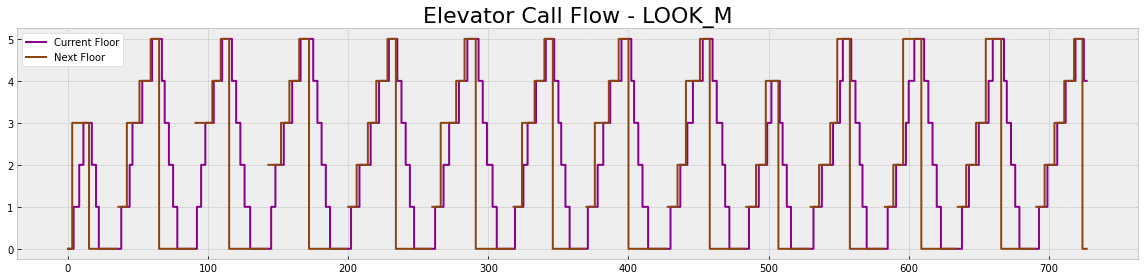

In [27]:
plt.step(np.arange(0, elevator_current_floor.shape[0]), elevator_current_floor, label='Current Floor')
plt.step(np.arange(0, elevator_next_floor.shape[0]), elevator_next_floor, label='Next Floor')

plt.yticks(np.arange(0, parameters.num_floors))
# plt.xlim(0, 200)
plt.title(f'Elevator Call Flow - {dispatching_algorithm}')
plt.legend(loc='upper left', facecolor='white', framealpha=1)
plt.tight_layout()
plt.show()

In [28]:
# for i in (np.diff(df.iloc[0:].index.to_numpy())):
#     print(f'{i:.2f}')

In [29]:
# for time, elevator, queues in zip(df.iloc[0:].index.to_numpy(), df.iloc[0:]['elevator'].to_numpy(), df.iloc[0:]['floors_queues'].to_numpy()):
    
#     print(f'{pd.to_datetime(time, unit="s").strftime("%M-%S-%f")} - {elevator.state} - {elevator.doors} - CURR = {elevator.current_floor} - NEXT = {elevator.next_floor} - PEOP. = {len(elevator.current_people)} - Q1-{len(queues[1])} - Q2-{len(queues[2])} - Q3-{len(queues[3])} - Q4-{len(queues[4])} - Q5-{len(queues[5])}')

## Outside and Inside Calls

In [30]:
elevator_calls = []
for elevator in elevator_data:
    elevator_calls.append(elevator.calls)

unique_calls = set([item for sublist in elevator_calls for item in sublist])

outside_calls_floor = [call.floor for call in unique_calls if call.type_=='outside']
inside_calls_floor = [call.floor for call in unique_calls if call.type_=='inside']

unique_outside, counts_outside = np.unique(outside_calls_floor, return_counts=True)
unique_inside, counts_inside = np.unique(inside_calls_floor, return_counts=True)

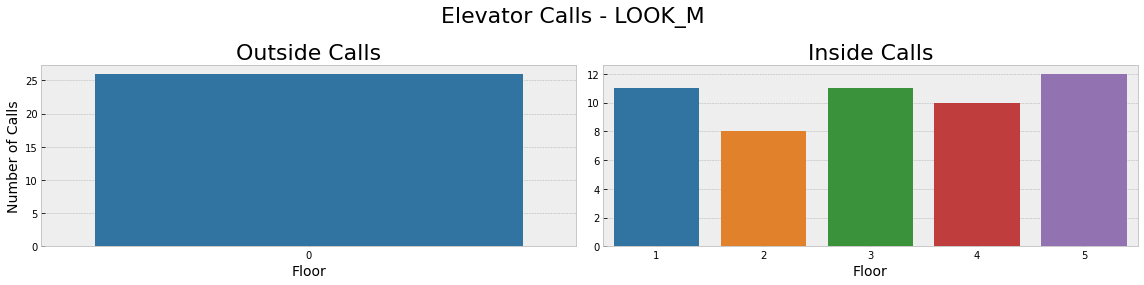

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(x=unique_outside, y=counts_outside, palette='tab10', zorder=2, ax=axes[0])
axes[0].set_xlabel('Floor')
axes[0].set_ylabel('Number of Calls')
axes[0].set_title('Outside Calls')

sns.barplot(x=unique_inside, y=counts_inside, palette='tab10', zorder=2, ax=axes[1])
axes[1].set_xlabel('Floor')
axes[1].set_title('Inside Calls')

plt.suptitle(f'Elevator Calls - {dispatching_algorithm}', fontsize=22)
plt.tight_layout()
plt.show()

## Elevator Usage Proportion

In [32]:
elevator_state = []
for elevator in elevator_data:
    elevator_state.append(elevator.state)
elevator_state = np.array(elevator_state)

idle_proportion = np.mean(elevator_state == 'idle')
busy_proportion = np.mean((elevator_state == 'up') | (elevator_state == 'down'))

display(Markdown(f'#### {dispatching_algorithm}'))
display(Markdown(f'#### Idle Time : {simulation_duration * idle_proportion / 60 :.3g} minutes'))
display(Markdown(f'#### Busy Time : {simulation_duration * busy_proportion / 60 :.3g} minutes'))

#### LOOK_M

#### Idle Time : 0 minutes

#### Busy Time : 20 minutes

## Elevator People Level

In [33]:
people_level = []
for elevator in elevator_data:
    people_level.append(len(elevator.current_people))
    
people_unique, people_counts = np.unique(people_level, return_counts=True)
counts_proportions = people_counts / len(people_level)

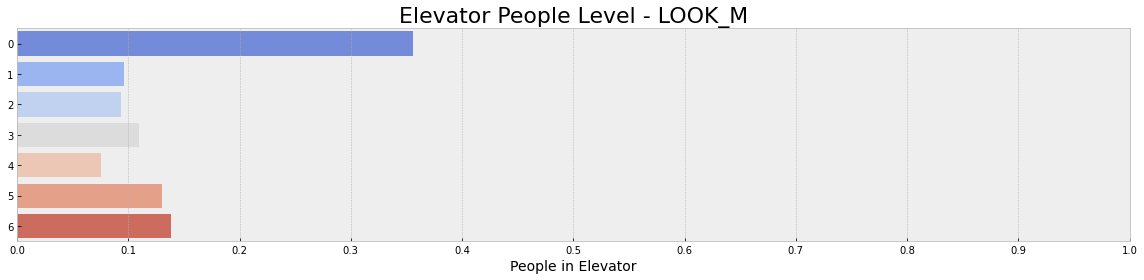

In [34]:
sns.barplot(y=people_unique, x=counts_proportions, orient='h', palette='coolwarm')

plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))

plt.xlabel('People in Elevator')
plt.ylabel('')
plt.title(f'Elevator People Level - {dispatching_algorithm}')
plt.tight_layout()
plt.show()

## User Waiting Time

In [35]:
num_users_served = len(users_served)

time_in_queue = []
time_in_elevator = []
time_in_system = []

for user in users_served:
    time_in_queue.append(user.enter_elevator_time - user.arrive_time)
    time_in_elevator.append(user.arrive_destination_time - user.enter_elevator_time)
    time_in_system.append(user.arrive_destination_time - user.arrive_time)

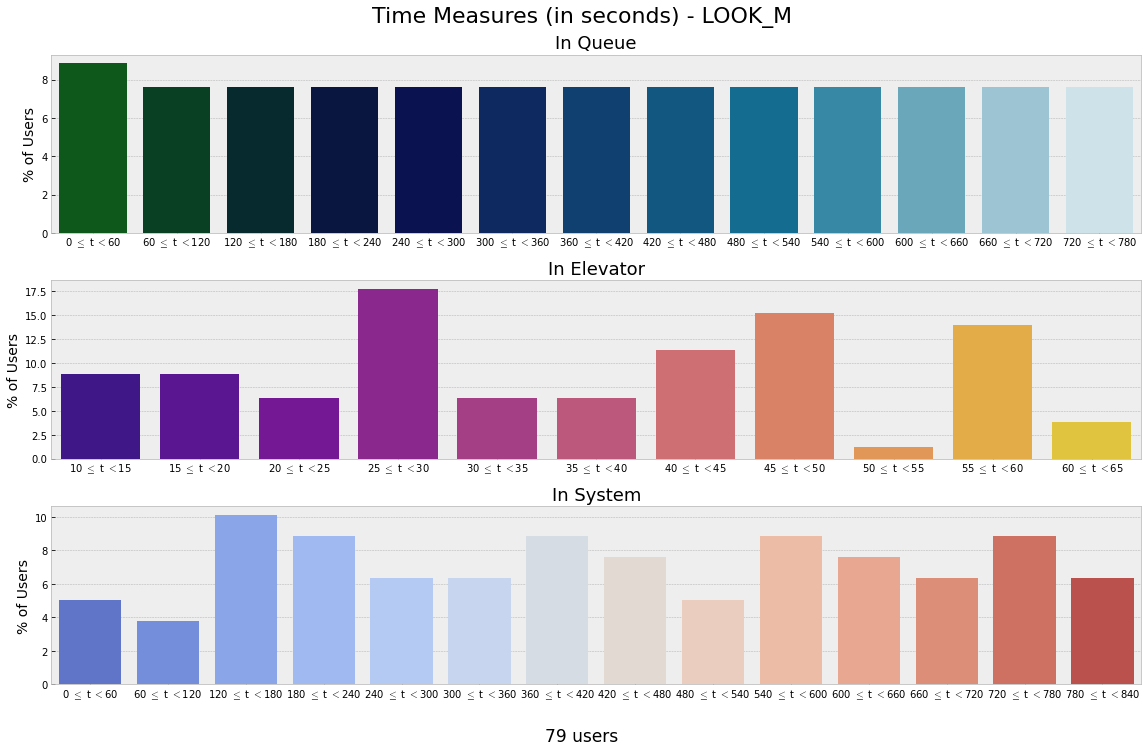

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

lists = [time_in_queue, time_in_elevator, time_in_system]
titles = ['In Queue', 'In Elevator', 'In System']
intervals = [60, 5, 60]
palettes = ['ocean', 'plasma', 'coolwarm']

threshold = 0.01

for ax, list_, interval, title, palette in zip(axes.flatten(), lists, intervals, titles, palettes):

    max_ = interval * np.round(np.max(list_) / interval)
    divisions = np.arange(0, max_ + interval, interval).astype(int)

    xticklabels = []
    counts = []
    for i in range(1, len(divisions)):
        xticklabels.append(f'{divisions[i-1]} $\leq$ t $<${divisions[i]}')
        counts.append(len(np.where((list_ >= divisions[i-1]) & (list_ < divisions[i]))[0]))
    counts = np.array(counts)

    counts[counts < num_users_served * threshold] = 0
    xticklabels = np.delete(xticklabels, np.where(counts == 0))
    counts = counts[counts > 0]
    unique = np.arange(0, counts.shape[0])
    counts_percentage = counts / counts.sum() * 100
    
    sns.barplot(x=unique, y=counts_percentage, zorder=2, palette=palette, ax=ax)
    ax.set_xticks(unique)
    ax.set_xticklabels(xticklabels)
    ax.set_ylabel('% of Users')
    ax.set_title(title, fontsize=18)

plt.figtext(0.5, -0.04, f'{num_users_served} users', fontsize=17, ha='center')
plt.suptitle(f'Time Measures (in seconds) - {dispatching_algorithm}', fontsize=22)
plt.tight_layout()
plt.show()

In [37]:
statistics = []
for list_ in lists:
    statistics.append((np.mean(list_), np.quantile(list_, 0.25), np.quantile(list_, 0.75)))

statistics = np.array(statistics)

display(Markdown(f'#### {dispatching_algorithm} - In minutes'))
pd.DataFrame(data=statistics/60, index=titles, columns=['Mean', '25th', '75th']).round(2)

#### LOOK_M - In minutes

,Mean,25th,75th
In Queue,6.54,3.36,9.60
In Elevator,0.60,0.42,0.78
In System,7.14,3.85,10.11
